# Homework 3：Actor-Critic Algorithm and Dyna Q algorithm
## Due: 23:59:59 (GMT +08:00), April 18, 2024 ##
**The homework contains two parts：ActorCritic algorithm and Dyna Q algorithm. You need to implement the two alogithms and answer the questions.**

# Section 1 Dyna-Q and Dyna-Q+

### Environment--Maze problem

In the first simple maze problem shown in Figure 1 (**basic**), there are four actions, **up**, **down**, **right**, and **left**, which take the agent deterministically to the corresponding neighboring states, except when movement is blocked by an obstacle or the outer boundary of the maze, in which case the agent remains where it is. 

Reward is zero on all state-action pairs, except those transiting to the goal state, on which the reward is **+1**, i.e., **r(s, a) = 1** when the
**next state s′ = G** and **r(s, a) = 0 otherwise**.

After reaching the goal state (G), the agent returns to the start state (S) to begin a new episode.

!["figure 1"](./pic1.png)

*Figure 1*

In the second blocking maze problem (**blocking**) shown in Figure 2, initially, there is a short path from start to goal, along the right-hand side boundary of the maze, as shown in the left subfigure of Figure 2. 

After 5000 time steps, the short path is “blocked”, and a longer path is opened up along the left-hand side boundary of the maze, as shown in the right subfigure of Figure 2. Other basic settings are the same as the first simple maze problem.

!["figure 2"](./pic2.png)

*Figure 2*

In the third shortcut maze problem (**cut**) shown in Figure 3, initially, the optimal path is to go around the left side of the boundary (left subfigure of Figure 3). 

After 3000 time steps, however, a shorter path is opened up along the right side, without changing the original path (right subfigure of Figure3). And other basic settings are the same as the first problem.

!["figure 3"](./pic3.png)

*Figure 3*


In [57]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random
import time
class Maze:
    def __init__(self, ncol = 9, nrow = 6, model = "basic"):
        self.nrow = nrow
        self.ncol = ncol
        self.x = 0  # the current position (x) of agent 
        self.y = self.nrow - 1  # the current position (y) of agent
        self.time_counter = 0
        self.model = model
        if model == "basic":
            self.barrier = [[2, 2], [2, 3], [2, 4], [5, 1], [7, 3], [7, 4], [7, 5]]
            self.start = [0, 3]
            self.end = [8, 5]
        if model == "blocking":
            self.barrier = [[0, 2], [1, 2], [2, 2], [3, 2], [4, 2], [5, 2], [6, 2], [7, 2]]
            self.start = [3, 0]
            self.end = [8, 5]
        if model == "cut":

            self.barrier = [[8, 2], [1, 2], [2, 2], [3, 2], [4, 2], [5, 2], [6, 2], [7, 2]]
            self.start = [3, 0]
            self.end = [8, 5]

    def step(self, action):  # 

        # 4 kinds of actions: change[0]:up , change[1]:down, change[2]:left, change[3]:right  
        
        
        # original (0,0) on the top left
        change = [[0, -1], [0, 1], [-1, 0], [1, 0]]
        newx = min(self.ncol - 1, max(0, self.x + change[action][0]))
        newy = min(self.nrow - 1, max(0, self.y + change[action][1]))
        if [newx, newy] not in self.barrier:
            self.x = newx
            self.y = newy
        next_state = self.y * self.ncol + self.x
        reward = 0
        done = False
        if self.x==self.end[0] and self.y==self.end[1]:  # next position is the terminal
            done = True
            reward = 1
        #print(self.x, self.y)
        self.time_counter += 1
        if self.time_counter > 5000 and self.model == "blocking":
            self.barrier = [[8, 2], [1, 2], [2, 2], [3, 2], [4, 2], [5, 2], [6, 2], [7, 2]]
        if self.time_counter > 3000 and self.model == "cut":
            self.barrier = [[1, 2], [2, 2], [3, 2], [4, 2], [5, 2], [6, 2], [7, 2]]
        return next_state, reward, done

    def reset(self):  # return to start point
        #self.time_counter = 0
        self.x = self.start[0]
        self.y = self.start[1] 
        return self.y * self.ncol + self.x

### In this part, we try to implement two algorithms：(A) Dyna-Q and (B) Dyna-Q+

#### Dyna-Q

The Dyna-Q algorithm is to repeat the following steps: (1) Learning and (2) Planning

Learning step is the same as Q-learning , at current state $S$ , we take action $A$ with $\epsilon-greedy$ policy ,then we get rewards $R$ and next state $S'$ from environment. We update the Q-table by the following formula: 
$$ Q(S,A)\leftarrow Q(S,A)+\alpha[R+\gamma  max_{a} Q(S',a)- Q(S,A)] $$

Then we predict state transition as following:
$$Model(S,A) \leftarrow R,S'$$

Planning does not need to interact with the environment , every planning step samples a visited pair $(S,A)$ firstly, obtain relevant $(R,S')$ from $Model(R,A)$ ,and update Q-table by following formula , the planning step will repeat n times:
$$ Q(S,A)\leftarrow Q(S,A)+\alpha[R+\gamma  max_{a} Q(S',a)- Q(S,A)] $$

**Coding exercise.** Here you are require to implete $q_learning()$ and $update()$ in Class DynaQ.


In [58]:
class DynaQ:
    """ Dyna-Q """
    def __init__(self,
                 ncol,
                 nrow,
                 epsilon,
                 alpha,
                 gamma,
                 n_planning,
                 n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])  # initial Q table
        self.n_action = n_action  # num of actions
        self.alpha = alpha  # learning rate
        self.gamma = gamma  # discount factor
        self.epsilon = epsilon  # epsilon-greedy

        self.n_planning = n_planning  # num of times to conduct q-planning
        self.model = dict()  #  env model

    def check(self, state):
        if self.Q_table[state][0] == self.Q_table[state][1] == self.Q_table[state][2] == self.Q_table[state][3]:
            return True
        return False

    def take_action(self, state):  #epsilon greedy
        if np.random.random() < self.epsilon or self.check(state):
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action

    def q_learning(self, s0, a0, r, s1):
        """ ------------- Programming 1: implement the updating of the Q table for Q-learning ------------- """
        """ YOUR CODE HERE """

        for i in range(self.n_action):
            if i == 0:
                max_q = self.Q_table[s1][i] 
            elif self.Q_table[s1][i] > max_q:
                max_q = self.Q_table[s1][i]
        self.Q_table[s0][a0] += self.alpha * (r + self.gamma * max_q - self.Q_table[s0][a0])
        """ ------------- Programming 1 ------------- """

    def update(self, s0, a0, r, s1):
        """ ------------- Programming 2: implement the updating of the Q table for DynaQ (you may use the function q_learning) ------------- """
        """ YOUR CODE HERE """
        self.q_learning(s0, a0, r, s1)
        self.model[(s0, a0)] = (r, s1)
        for i in range(self.n_planning):
            (s0, a0) = random.choice(list(self.model.keys()))
            r, s1 = self.model[(s0, a0)]
            self.q_learning(s0, a0, r, s1)
        """ ------------- Programming 2 ------------- """

#### Dyna-Q+

Dyna-Q+ is similar to Dyna-Q , the only difference between them is the rewards fountion in planning step . We take a new reward $r = r + c \sqrt t$ , $c$ is a exploration factor and $t$ is  the time since agent last reached state S

**Coding exercise.** Simiarily , you are require to implete $q_learning()$ and $update()$ in Class $DynaQ_Plus$

In [61]:
class DynaQ_Plus:
    """ Dyna-Q+ """
    def __init__(self,
                 ncol,
                 nrow,
                 epsilon,
                 alpha,
                 gamma,
                 kappa,
                 n_planning,
                 n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])  # initial Q table
        self.n_action = n_action  # num of actions
        self.alpha = alpha  # learning rate
        self.gamma = gamma  # discount factor
        self.epsilon = epsilon  # epsilon-greedy

        self.n_planning = n_planning  # num of times to conduct q-planning
        self.model = dict()  # 

        self.time = 0
        self.kappa = kappa

    def check(self, state):
        if self.Q_table[state][0] == self.Q_table[state][1] == self.Q_table[state][2] == self.Q_table[state][3]:
            return True
        return False

    def take_action(self, state):  # epsilon greedy
        if np.random.random() < self.epsilon or self.check(state):
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    def q_learning(self, s0, a0, r, s1):
        """ ------------- Programming 1: implement the updating of the Q table for Q-learning ------------- """
        """ YOUR CODE HERE """
        for i in range(self.n_action):
            if i == 0:
                max_q = self.Q_table[s1][i] 
            elif self.Q_table[s1][i] > max_q:
                max_q = self.Q_table[s1][i]
        self.Q_table[s0][a0] += self.alpha * (r + self.gamma * max_q - self.Q_table[s0][a0])
        """ ------------- Programming 1 ------------- """

    def update(self, s0, a0, r, s1):
        """ ------------- Programming 2: implement the updating of the Q table for DynaQ (you may use the function q_learning) ------------- """
        """ Hint self.model can be in : {(s0,a): (r,s1,times)}"""
        """ YOUR CODE HERE """
        self.time += 1
        self.q_learning(s0, a0, r, s1)
        if (s0, a0) not in self.model:
            for action in range(self.n_action):
                self.model[(s0, action)] = 0, s0, 0
        self.model[(s0, a0)] = (r, s1, self.time)
        for i in range(self.n_planning):
            (s0, a0) = random.choice(list(self.model.keys()))
            r, s1, time= self.model[(s0, a0)]
            r += self.kappa * np.sqrt(self.time - time)
            self.q_learning(s0, a0, r, s1)


## Running two algorithms in the Maze environment and  Visualization

Here, we try to run two algorithms in our environment. You should run the following code without editing and answer **Questions 1** based on the output. **Your output will be one of the criteria we use to score**.


You also can change the hyperparameters privately to get a better understanding of these two algorithms. 

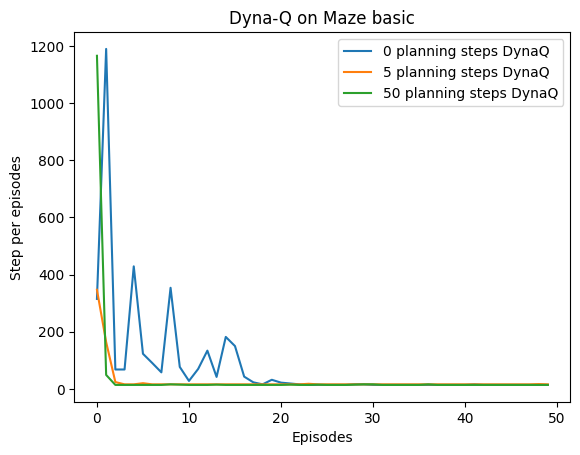

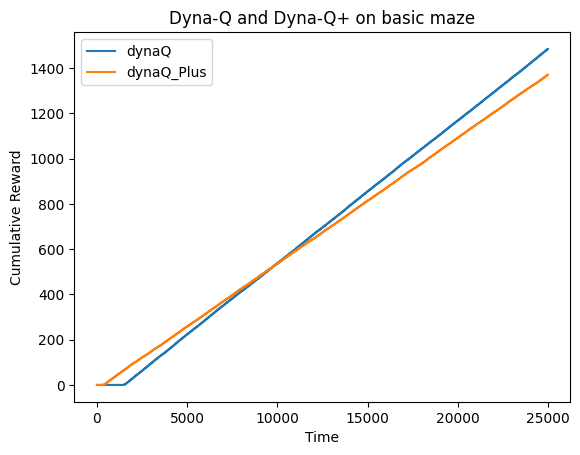

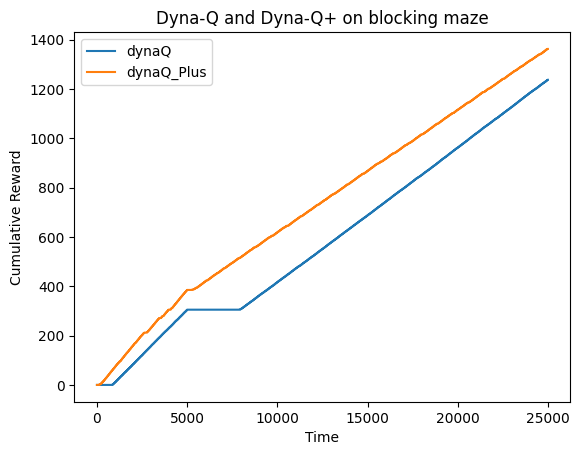

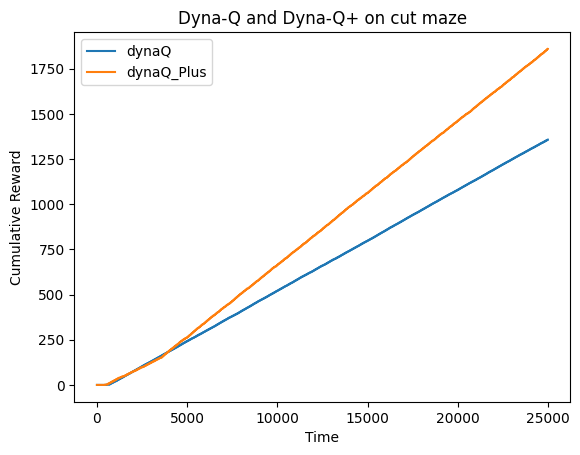

In [62]:

maze_list=["basic","blocking","cut"]
n_planning_list = [0, 5, 50] ##
agent_list=["dynaQ","dynaQplus"]
ncol = 9 ## size of env
nrow = 6 ## size of env
epsilon = 0.01 ## epsilon-greedy
alpha = 0.1 ## learning rate
gamma = 0.95 ## discount factor
kappa=1e-3  
num_episodes = 50  # num of episodes

SEED = 6
random.seed(SEED)
np.random.seed(SEED)


##### Part 1 Visualization
##### We are going to analyse the impact of "n_planing" , we take this part in Maze "basic" and agent "DynaQ" 

for n_planning in n_planning_list:
    

    env = Maze(ncol, nrow, model="basic")
    agent_name="DynaQ"
    agent = DynaQ(ncol, nrow, epsilon, alpha, gamma, n_planning)

    return_list = []  
        
           
    for i_episode in range(num_episodes):  
        episode_return = 0
        state = env.reset()
        done = False
        t_count = 0
        while not done:
            action = agent.take_action(state)
            next_state, reward, done = env.step(action)
            episode_return += reward  
            t_count += 1
            agent.update(state, action, reward, next_state)
            state = next_state
        return_list.append(t_count)

        #return_list = DynaQ_Maza(n_planning)
        episodes_list = list(range(len(return_list)))
    plt.plot(episodes_list,
        return_list,
        label=str(n_planning) + ' planning steps '+ str(agent_name))
plt.legend()
plt.xlabel('Episodes')
plt.ylabel('Step per episodes')
plt.title('Dyna-Q on {}'.format('Maze '+"basic"))
plt.show()


##### Part 2 Visualization
##### We are going to analyse the difference between agent "DynaQ" and agent "DynaQ+"

for maze in maze_list:
    for agent_type in ["dynaQ", "dynaQ_Plus"]:
        epsilon = 0.1
        alpha = 1
        gamma = 0.95
        n_planning = 20
        num_episodes = 20  


        ### reset  env
        if maze == "basic":
            env = Maze(ncol, nrow, model="basic")
        if maze == "blocking":
            env = Maze(ncol, nrow, model="blocking")
        if maze == "cut":
            env = Maze(ncol, nrow, model="cut")    

        ### reset agent
        if agent_type=="dynaQ":
            agent = DynaQ(ncol, nrow, epsilon, alpha, gamma, n_planning)
        else:
            agent = DynaQ_Plus(ncol, nrow, epsilon, alpha, gamma, kappa, n_planning)



        time_step = 0
        cumulative_reward = np.zeros(25000)

        while time_step < 25000:
            state = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, done = env.step(action)
                time_step += 1
                if time_step>=25000:
                    break
                cumulative_reward[time_step] = cumulative_reward[time_step-1] + reward
                agent.update(state, action, reward, next_state)
                state = next_state
        time_list = list(range(len(cumulative_reward)))
        plt.plot(time_list, cumulative_reward, label = agent_type)
    plt.legend()
    plt.xlabel('Time')
    plt.ylabel('Cumulative Reward')
    plt.title('Dyna-Q and Dyna-Q+ on {}'.format(maze + ' maze'))
    plt.show()

**Questions.**

**(a)** What are the impacts of the number of planning steps on the performances of algorithms and
what is the reason?

planning越长，DynaQ算法越快收敛（耗时越短）；原因是planning会利用之前的经验更新Q函数

**(b)** What are the differences between the performance of Dyna-Q and that of Dyna-Q+ in three
environments? Please discuss the reason for these differences

环境1算法表现差异不大，因为环境1稳定，善于冒险的DynaQ+在前期学得奖励较多，随着时间变长，两者都探索到了全局环境，偏于保守的DynaQ将回报最大化。

环境2（blocking）在环境变化后，DynaQ+由于前期对环境进行了更多的探索，累计回报增速只是轻微减缓，而DynaQ的累计回报在停滞一段时间（更新未探索环境的Q函数，尚未发现新路径）后，重回原先的回报增速。

环境3（cut）在环境变化后，DynaQ+由于前期对环境进行了更多的探索，迅速选择了较短的新路径，回报增速提升, 而DynaQ依赖旧的远路，表现较差。

原因是DynaQ+通过对未经常访问状态的额外探索，更适合应对环境的变化；在相对稳定的环境中，两者的性能差异可能不大。


# Section 2：Advantage ActorCritic algorithm (A2C)

## Policy Gradient
We need parametrized strategy for the policy based method. We assume the target strategy $\pi_\theta$ is a stochastic policy and is differentiable everywhere, where $\theta$ is the corresponding parameter. Our goal is to find an optimal strategy to maximize the expected reward of this strategy in the environment. We define the object function of our strategy learning as:
$$
J(\theta)= V^{\pi_\theta}(s_0),
$$
where $s_0$ is the initial state.Now with the object function, we compute its derivation over the strategy $\theta$, and use gradient-ascent to maximize the object function and get the optimal policy.

We have learned the state access distribution under policy $\pi$，and here we denote it as $d^{\pi}$. Then we compute the gradient of the object function and get

$$
\begin{align}
\nabla_{\theta}J(\theta)
&\propto \sum_{s \in S}d^{\pi}(s)\sum_{a \in A}Q^{\pi}(s,a)\nabla_{\theta}\pi_{\theta}(a|s)\\
&=\sum_{s \in S}d^{\pi}(s)\sum_{a \in A}\pi_{\theta}(a|s)Q^{\pi}(s,a)\frac{\nabla_{\theta}\pi_{\theta}(a|s)}{\pi_{\theta}(a|s)}\\
&= \mathbb{E}_{\pi}[Q^{\pi}(s,a)\nabla_{\theta}\ln \pi_{\theta}(a|s)]
\end{align}.
$$
So, we can use the gradient to update the policy. Generally, we can write the gradient as
$$
g = \mathbb{E}[\sum^{\infty}_{t=0}\psi_{t}\nabla_{\theta}\log \pi_{\theta}(a_{t}|s_{t})],
$$
where $\psi_{t}$ can be：

$$
Q^{\pi}(s_{t},a_{t})-V^{\pi}(s_{t})
$$
for ActorCritic algorithm and 
$$
r_{t} + \gamma V^{\pi}(s_{t+1}) - V^{\pi}(s_t)
$$
for Advantage ActorCritic algorithm.

## Advantage ActorCritic (A2C) algorithm

The Advantage ActorCritic algorithm is: 
$$

\psi_{t}=r_{t} + \gamma V^{\pi}(s_{t+1}) - V^{\pi}(s_t).

$$

The updating procedure is：
$$
\begin{align}
&\text{1.Initialize the strategy parameter} \quad \theta \\
&\text{2.Use current strategy} \pi_{\theta} \text{to sample the trajectory} \quad \{s_{1},a_{1},r_{1},s_{2},a_{2},r_{2} ... s_{t},a_{t},r_{t}\}\\
&\text{3.Compute the reward of the current trajectory} \quad \sum_{t'=t}^{\infty}\gamma^{t'-t}r_{t'} as \psi_{t}\\
&\text{4.Update over} \quad \theta: \theta = \theta + \alpha \psi_{t}\nabla_{\theta}\log \pi_{\theta}(a_{t}|s_{t})\\
&\text{5.Repeat step} \quad 2-4
\end{align}
$$

Alright! Now let's see how it performes using python!



## Implementation
We experiment the A2C algorithm in the Cartpole environment. First we load packages.

In [63]:
import gym
import torch
import torch.nn.functional as F
from torch import nn
from torch.distributions import Categorical, Normal
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import random

if torch.cuda.is_available():
    device = "cuda:0"

else:
    device = "cpu"
print(device)
eps = np.finfo(np.float32).eps.item()

cuda:0


In [64]:
def smooth_curve(y, smooth):
    r = smooth
    length = int(np.prod(y.shape))
    for i in range(length):
        if i > 0:
            if (not np.isinf(y[i - 1])) and (not np.isnan(y[i - 1])):
                y[i] = y[i - 1] * r + y[i] * (1 - r)
    return y

def moving_average(y, x=None, total_steps=100, smooth=0.9, move_max=False):
    if isinstance(y, list):
        y = np.array(y)
    length = int(np.prod(y.shape))
    if x is None:
        x = list(range(1, length+1))
    if isinstance(x, list):
        x = np.array(x)
    if length > total_steps:
        block_size = length//total_steps
        select_list = list(range(0, length, block_size))
        select_list = select_list[:-1]
        y = y[:len(select_list) * block_size].reshape(-1, block_size)
        if move_max:
            y = np.max(y, -1)
        else:
            y = np.mean(y, -1)
        x = x[select_list]
    y = smooth_curve(y, smooth)
    return y, x
def plotReward(infos):
    x, y = infos["episodes"],infos["rewards"]
    y, x = moving_average(y, x)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.plot(x, y)
    plt.show()

Define basic network unit Net.

In [65]:
class Net(torch.nn.Module):
    def __init__(self, hidden_size, input_size, output_size, layer_num=2):
        super(Net, self).__init__()
        # Use torch.nn.ModuleList or torch.nn.Sequential For multiple layers
        layers = []
        last_size = input_size
        for i in range(layer_num-1):
            layers.append(torch.nn.Linear(last_size, hidden_size))
            layers.append(torch.nn.ReLU())
            last_size = hidden_size
        layers.append(torch.nn.Linear(last_size, output_size))
        self._net = torch.nn.Sequential(*layers)

    def forward(self, inputs):
        return self._net(inputs)

Define basic class RLAlgo in the A2C algorithm.

**Coding exercise.** Please implement function dist to calculate probability of action.

In [79]:
def trans2tensor(batch):
    for k in batch:
        # print(batch[k])
        if isinstance(batch[k], torch.Tensor):
            batch[k] = batch[k].to(device=device)
        elif isinstance(batch[k][0], torch.Tensor):
            batch[k] = torch.cat(batch[k]).to(device=device)
        else:
            batch[k] = torch.tensor(batch[k], device=device, dtype=torch.float32)

    return batch


class RLAlgo:
    def __init__(self, discrete_action=True, tau=0.01):
        self.discrete_action = discrete_action
        self._tau = tau

    # update target network
    def soft_update(self, source, target, tau=None):
        if tau is None:
            tau = self._tau
        with torch.no_grad():
            for target_param, param in zip(target.parameters(), source.parameters()):
                target_param.data.copy_(target_param.data * (1.0 - tau) + param.data * tau)

    # sample actions
    def action(self, state):
        with torch.no_grad():
            p_out = self.policy(state)
        log_prob, action = self.dist(p_out)
        return action, log_prob

    # calculate probability of action
    def dist(self, p_out, action=None):
        if self.discrete_action:
            """YOUR CODE HERE"""
            # ========================================
            # 【Coding 1】: Hints:
            #  1. output p_out according to the policy net，use softmax to compute the distribution of action (action_dist).
            #  2. if action is None，get action according to the action distribution；If not, use the input action.
            #  3. get the probability of each action (log_prob) according to the specific action and the distribution of action. 
            # ========================================
            action_dist = torch.nn.functional.softmax(p_out, dim=1)
            m = Categorical(action_dist)
            if action is None:
                action = m.sample()
            log_prob = m.log_prob(action.T)
            """END CODE HERE"""
        else:
            # only for pendulum env
            mean, var = torch.chunk(p_out, 2, dim=-1)
            mean = 2 * torch.tanh(mean)
            var = torch.nn.functional.softplus(var)
            m = Normal(mean, var)
            if action is None:
                action = m.sample()
                action = torch.clamp(action, -2, 2)
            log_prob = m.log_prob(action)

        return log_prob.reshape(-1, 1), action.reshape(-1, 1)

    # compute advantage
    def compute_adv(self, batch, gamma):
        s = batch["state"]
        r = batch["reward"].reshape(-1, 1)
        s1 = batch["next_state"]
        done = batch["done"].reshape(-1, 1)
        with torch.no_grad():
            adv = r + gamma * (1 - done) * self.value(s1) - self.value(s)
        return adv

**Coding exercise.** Please implement the A2C algorithm. Note that there are three network: actor network, value network and target value network. The target value network is updated by soft_update function in class RLAlgo.

During the update of agent, we write th loss function as $L=(r_{t} + V^{\pi}(s_{t+1}) - V^{\pi}(s_t)) \log\pi_{\theta}(a_{t}|s_{t})$，and computing the derivative over $\theta$ can update the policy.


In [85]:
class AdvantageActorCritic(RLAlgo):
    def __init__(
            self,
            hidden_size,
            state_space,
            action_space,
            actor_lr,
            critic_lr,
            **kwargs
    ):
        super(AdvantageActorCritic, self).__init__(**kwargs)
        self.action_space = action_space

        input_size = state_space.shape[0]
        if self.discrete_action:
            output_size = action_space.n
        else:
            output_size = action_space.shape[0] * 2
            
        """YOUR CODE HERE"""
        actorNet = Net(hidden_size, input_size, output_size)
        valueNet = Net(hidden_size, input_size, 1)
        targetvalueNet = Net(hidden_size, input_size, 1)
        self.policy = actorNet.to(device=device)
        self.value = valueNet.to(device=device)
        self.target_value = targetvalueNet.to(device=device)
        self.actor_optimizer = torch.optim.Adam(self.policy.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.value.parameters(), lr=critic_lr)
        """END CODE HERE"""

    def update(self, batch, gamma):
        s = batch["state"]
        a = batch["action"].reshape(-1, 1)
        r = batch["reward"].reshape(-1, 1)
        s1 = batch["next_state"]
        done = batch["done"].reshape(-1, 1)

        """YOUR CODE HERE"""
        adv = batch["adv"]
        log_prob, _ = self.dist(self.policy(s), a)
        loss = torch.mean(log_prob * adv)
        # for i in range(len(s)):
        #     loss += adv[i] * self.dist(self.policy(s[i]), a[i])[0]
        loss.backward()
        self.actor_optimizer.step()
        
        value_loss = F.mse_loss(self.value(s), r + gamma * (1 - done) * self.target_value(s1))
        value_loss.backward()
        self.critic_optimizer.step()
        self.soft_update(self.value, self.target_value)
        
        """END CODE HERE"""

Now let's do experiment and see the performance of the algorithm in Carpole environment!

In [86]:
env_name = "CartPole-v1"
env = gym.make(env_name)

In [87]:
max_timesteps = 1000
gamma = 0.98


def train(agent, num_episode=1000, mini_epoch=5, discrete_action=True, print_every=100):
    rewards_log = []
    episodes_log = []
    for i_episode in range(num_episode):
        states = []
        acts = []
        rewards = []
        next_states = []
        log_probs = []
        dones = []

        state, _ = env.reset(seed=1)
        # env.reset(seed=1)
        random.seed(1)

        state = torch.tensor([state], device=device, dtype=torch.float32)

        for time_step in range(max_timesteps):
            action, log_prob = agent.action(state)
            action = action.cpu()
            if discrete_action:
                next_state, reward, done, _, _ = env.step(action.numpy().reshape(-1)[0])
            else:

                next_state, reward, done, _, _ = env.step(action.numpy().reshape(-1))

            # collect samples
            states.append(state)
            acts.append(action)
            log_probs.append(log_prob.detach())
            rewards.append(reward)
            next_states.append(next_state)
            dones.append(done)
            # log_probs.append(log_prob)

            state = torch.tensor([next_state], device=device, dtype=torch.float32)
            if done:
                break
        rewards_log.append(np.sum(rewards))
        episodes_log.append(i_episode)
        batch = trans2tensor({"state": states, "action": acts,
                              "log_prob": log_probs,
                              "next_state": next_states, "done": dones,
                              "reward": rewards, })
        r = batch["reward"]
        if not discrete_action:
            batch["reward"] = (r - r.mean()) / (r.std() + 1e-8)
        batch["adv"] = agent.compute_adv(batch, gamma)
        for i in range(mini_epoch):
            agent.update(batch, gamma)
        if (i_episode + 1) % print_every == 0 or i_episode + 1 == num_episode:
            print("Episode: {}, Reward: {}".format(i_episode + 1, np.mean(rewards_log[-10:])))
    # env.close()
    infos = {
        "rewards": rewards_log,
        "episodes": episodes_log
    }
    return infos

In the CartPole-v1 environment，let's see how each Episode scores!

Episode: 100, Reward: 69.8
Episode: 200, Reward: 58.3
Episode: 300, Reward: 117.4
Episode: 400, Reward: 70.8
Episode: 500, Reward: 59.4
Episode: 600, Reward: 57.7
Episode: 700, Reward: 61.2
Episode: 800, Reward: 64.3
Episode: 900, Reward: 91.0
Episode: 1000, Reward: 61.4
Episode: 1100, Reward: 43.9
Episode: 1200, Reward: 37.9
Episode: 100, Reward: 64.9
Episode: 200, Reward: 41.7
Episode: 300, Reward: 25.1
Episode: 400, Reward: 9.1
Episode: 500, Reward: 9.0
Episode: 600, Reward: 9.0
Episode: 700, Reward: 9.0
Episode: 800, Reward: 9.0
Episode: 900, Reward: 9.0
Episode: 1000, Reward: 9.0
Episode: 1100, Reward: 9.0
Episode: 1200, Reward: 9.0
Episode: 100, Reward: 47.6
Episode: 200, Reward: 9.0
Episode: 300, Reward: 9.0
Episode: 400, Reward: 9.0
Episode: 500, Reward: 9.0
Episode: 600, Reward: 9.0
Episode: 700, Reward: 9.0
Episode: 800, Reward: 9.0
Episode: 900, Reward: 9.0
Episode: 1000, Reward: 9.0
Episode: 1100, Reward: 9.0
Episode: 1200, Reward: 9.0


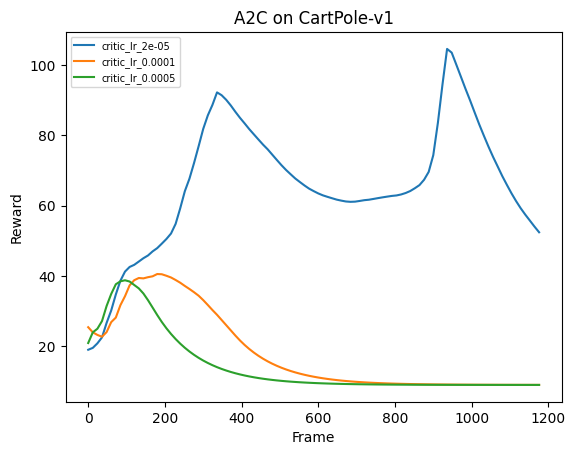

In [88]:
actor_lr = 1e-4
critic_lr = [2e-5, 1e-4, 5e-4]
hidden_size = 128

plt.title('A2C on {}'.format(env_name))
plt.ylabel("Reward")
plt.xlabel("Frame")

for i in range(len(critic_lr)):
    agent = AdvantageActorCritic(
        hidden_size,
        env.observation_space,
        env.action_space,
        actor_lr,
        critic_lr[i],
    )
    ac_cartpole_infos = train(agent, 1200, 10)
    infos = [ac_cartpole_infos, ]
    for info in infos:
        x, y = info["episodes"], info["rewards"]
        y, x = moving_average(y, x)
        plt.plot(x, y, label='critic_lr_'+str(critic_lr[i]))

plt.legend(prop={"size": 7})
plt.show()

**Question:** What can you infer from the plot about the relationship between the learning rate of critic and action?

较低的critic学习率（如2e-5）可能导致学习过程较为稳定，但学习进度较慢；而较高的批评者学习率（如5e-4）可能导致学习速度加快，但易产生不稳定性，可能导致性能下降。

critic的学习率比actor的学习率低时，agent可以在多轮相近的critic下探索并更新actor（进行策略提升），学到有用的信息，若critic的学习率大于等于actor， agent可能在多轮学习后无法获得稳定策略。